# Moving Average Crossover - Backtesting Strategy 
## Eli Lilly (LLY) - 2 years of real historical data

This notebook implements and backtests a **Moving Average Crossover** strategy on Eli Lilly stock 

the strategy generates buy/sell signals based on the crossover between a short-term (20-day) and long term (50-day) moving average, and compares performance against a simple **Buy & Hold** approach.

In [7]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Download real data for Eli Lilly
raw = yf.download("LLY", period="2y")
data = pd.DataFrame()
data["Close"] = raw["Close"].squeeze()

print(f"Data downloaded: {len(data)} trading days")
data.head()

[*********************100%***********************]  1 of 1 completed

Data downloaded: 500 trading days


,Close
Date,
2024-09-23,905.835938
2024-09-24,911.664307
2024-09-25,911.792480
2024-09-26,896.762939
2024-09-27,865.668335


## Moving Average Strategy 
The strategy uses two moving averages: 
 - **MA20** (short-term) - average of the last 20 days, react quickly to price changes 
 - **MA50** (long-term) - average of the last 50 days, reflects the broader trend 

 **Signal rules**
 - **Buy** when MA20 crosses **above** MA50 : short-term momentum beats long-term trend 
 - **Sell** when MA20 crosses **below** MA50: short-term momentum falls below long-term trend

In [8]:
# Calculate moving averages
data["MA20"] = data["Close"].rolling(window=20).mean()
data["MA50"] = data["Close"].rolling(window=50).mean()

# Generate signals
data["Signal"] = 0
data.loc[data["MA20"] > data["MA50"], "Signal"] = 1
data.loc[data["MA20"] < data["MA50"], "Signal"] = -1
data["Position"] = data["Signal"].diff()

# Crossover points only
buy_signals = data[data["Position"] == 2]
sell_signals = data[data["Position"] == -2]

print(f"Number of Buy signals: {len(buy_signals)}")
print(f"Number of Sell signals: {len(sell_signals)}")

Number of Buy signals: 5
Number of Sell signals: 5


## Price Chart with Buy & Sell Signals

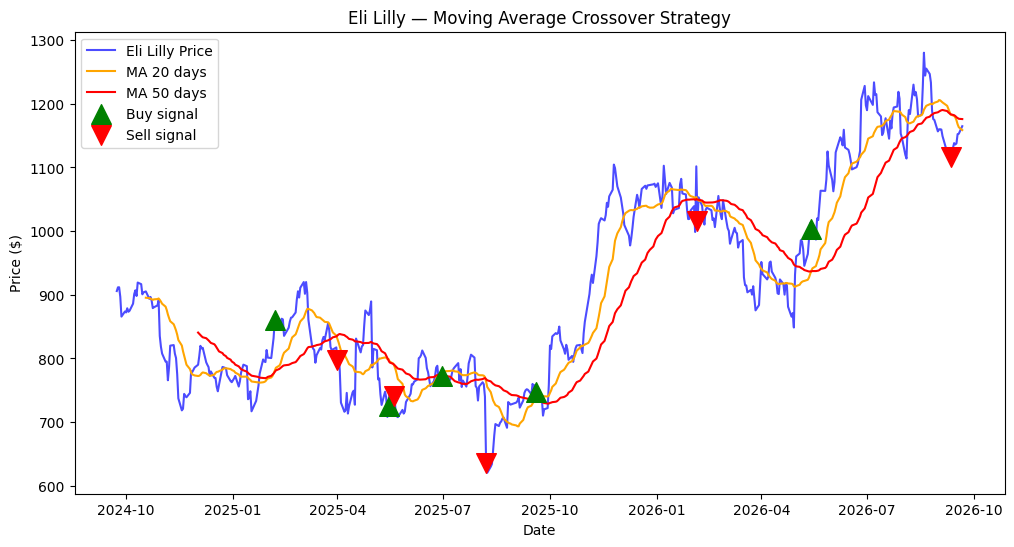

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(data["Close"], label="Eli Lilly Price", color="blue", alpha=0.7)
plt.plot(data["MA20"], label="MA 20 days", color="orange")
plt.plot(data["MA50"], label="MA 50 days", color="red")
plt.scatter(buy_signals.index, buy_signals["Close"],marker="^", color="green", s=200, label="Buy signal", zorder=5)
plt.scatter(sell_signals.index, sell_signals["Close"],marker="v", color="red", s=200, label="Sell signal", zorder=5)
plt.title("Eli Lilly — Moving Average Crossover Strategy")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

## Strategy Peformance vs Buy & Hold 

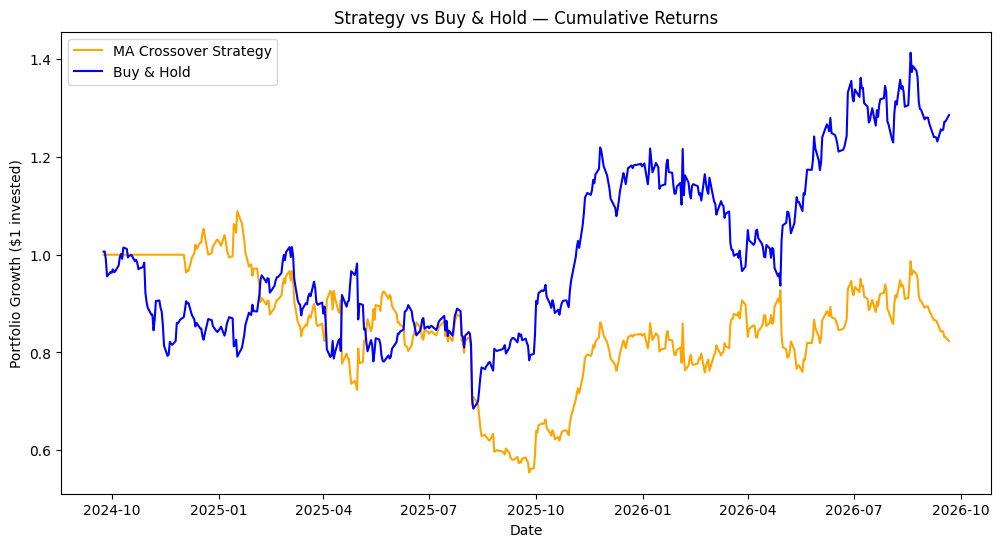

Strategy Performance vs Buy & Hold
----------------------------------------
Strategy return:   -17.71%
Buy & Hold return: 28.6%


In [10]:
# Calculate returns
data["Daily_Return"] = data["Close"].pct_change()
data["Strategy_Return"] = data["Signal"].shift(1) * data["Daily_Return"]

# Cumulative returns
cumulative_strategy = (1 + data["Strategy_Return"].dropna()).cumprod()
cumulative_buyhold = (1 + data["Daily_Return"].dropna()).cumprod()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(cumulative_strategy, label="MA Crossover Strategy", color="orange")
plt.plot(cumulative_buyhold, label="Buy & Hold", color="blue")
plt.title("Strategy vs Buy & Hold — Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Portfolio Growth ($1 invested)")
plt.legend()
plt.show()

# Print results
total_strategy = cumulative_strategy.iloc[-1] - 1
total_buyhold = cumulative_buyhold.iloc[-1] - 1

print("Strategy Performance vs Buy & Hold")
print("-" * 40)
print(f"Strategy return:   {round(float(total_strategy) * 100, 2)}%")
print(f"Buy & Hold return: {round(float(total_buyhold) * 100, 2)}%")

## Analysis & Conclusions

### Why did the strategy underperform ? 

The Moving Average Crossover strategy generated a **-17.71% return** compared to **+28.6% for Buy & Hold** over the same 2-year period.

Three key reasons explain this underperformance: 

1. **Strong uptrend** : Eli Lilly has been in a consistent bull market. In strongly trending markets, MA crossover strategies are always slightly late. They enter after the move has started and exit after it has ended. 

2. **Whipsaw effect** : The 5 sell signals forced exits at moments when the stock quickly recovered and continued higher, causing the strategy to miss significant gains. 

3. **No transaction costs modeled** : In reality, each buy/sell signal incurs commissions and bid-ask spreads, which would make the strategy perform even worse.

### When does this strategy work?

Moving Average Crossover strategies perform better in **sideways or volatile markets** with clear alternating trends — not on strongly trending assets like Eli Lilly.

### Possible improvements
- Test different MA periods (10/30, 50/200)
- Add a stop-loss to limit downside
- Combine with volume indicators for better signal quality